# **ICC ODI Cricket World Cup Data Analysis**

Yashi Jadhav | PHY/MAT 231| Spring 2026

# **Project Background**

My final project is about the ICC ODI Cricket World Cup data from 1975-2019. Cricket is a very popular sport and is played by many countries overseas, this project will focus on the One Day International format which typically is 50 overs long, with 6 balls played per over. Over 20 countries have played in this tournament, 6 of them playing every year since its inception.  

The dataset I will be using is titled CRICKET WORLD CUP SCORES(1975-2019). It contains the scores o all the cricket matches played in the world cup sources from the ICC Website and Cricbuzz website.The selected dataset has over 1000 rows of data, describing all the matches in each world cup year, the number of runs made in the game, wickets taken and lost, who played in the match, the venue, and overall world cup winner. The dataset can be found on Kaggle.com at https://www.kaggle.com/datasets/amalab182/cricket-world-cup-scores1975-2019

# **Research Questions**

Q1 - Does the host location present an advantage to certain teams? For teams who have won more than once, do they tend to win in the same host location or is there no correlation between the two?

Q2 - Who are the teams to beat? Which teams have the lowest amount of losses and does that correlate to more overall world cup wins?

Q3 - Which venues/locations had the best pitch? How do runs made on each location compare to each other and is there a specific location that's most advantageous?

# **Setup**

In [50]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import geopandas as gpd
import geodatasets
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
import math
import datetime
import sqlite3

# **ICC Cricket ODI World Cup 1975-2019 Dataset**

In [51]:
cricket = pd.read_csv('cricketworldcup.csv')
cricketold = pd.read_csv('cricketworldcupold.csv')

conn = sqlite3.connect(':memory:')
cricket.to_sql('cricket', conn, index=False)
cricketold.to_sql('cricketold', conn, index=False)

print(f"cricket table: {len(cricket)} rows, columns: {list(cricket.columns)}")
print(f"old cricket table: {len(cricketold)} rows, columns: {list(cricket.columns)}")

cricket table: 873 rows, columns: ['YEAR', 'TEAM', 'RUNS_SCORED', 'WICKETS_LOST', 'WICKETS_TAKEN', 'AGAINST', 'WINNER', 'VENUE', 'HOST_COUNTRY', 'CHAMPION']
old cricket table: 906 rows, columns: ['YEAR', 'TEAM', 'RUNS_SCORED', 'WICKETS_LOST', 'WICKETS_TAKEN', 'AGAINST', 'WINNER', 'VENUE', 'HOST_COUNTRY', 'CHAMPION']


## Column Header Descriptions

- Year - Year of the World Cup
- Team - Playing Team
- Runs Scored - Runs scored by the team
- Wickets Lost - Wickets lost while batting
- Wickets Taken - Wickets taken while bowling
- Against - Opposing Team
- Winner - Winner of the current match
- Venue - Location of the match
- Champion - Winner of the tournament

## Cleaning the Data

The dataset found on Kaggle was cleaned and filtered to become usable for this project. First, any extra rows were deleted to prevent errored values when sorting the values into a tables. Next, the "RESULT" column was changed into "WINNER", changing the value to the name of the winner of that match rather than the result "WIN" or "LOST" applying to the respective team. The last column was subsequently renamed "CHAMPION" as it desribes the overall champion of the tournament for the year in which that match was played.

Additionally, as many matches were canceled or abandoned due to weather, there were some matches that had no result. In the dataset they were marked with "NR" in all of the columns. To make the sorting process easier, I removed all of the NR games and focused only on games that were played.

## Initial Insights

Using basic functions like mean and sum we can look at some initial results from our dataset. Any columns with 

In [57]:
result = pd.read_sql_query("""
    SELECT AVG(RUNS_SCORED) as avg_runs_scored, SUM(RUNS_SCORED) as sum_runs_scored, MIN(RUNS_SCORED) as min_runs_scored, MAX(RUNS_SCORED) as MAX_runs_scored, AVG(WICKETS_LOST) as avg_wickets_lost, AVG(WICKETS_TAKEN) as avg_wickets_taken
    FROM cricket
""", conn)
result.head()


,avg_runs_scored,sum_runs_scored,min_runs_scored,MAX_runs_scored,avg_wickets_lost,avg_wickets_taken
0,219.07331,191251,36,417,7.24055,7.235968


From our results, we can see that on average each game is around 212, with the minimum being 36 and maximum being 417. Additionally we can see that the average wickets lost was around 7 while the average wickets taken was also around 7.

# **Question 1**

### Does the host location present an advantage to certain teams? For teams who have won more than once, do they tend to win in the same host location or is there no correlation between the two?

In [58]:
df = pd.read_sql_query("""
    SELECT YEAR, TEAM,RUNS_SCORED, WICKETS_LOST, WICKETS_TAKEN, AGAINST, WINNER, VENUE, CHAMPION 
    FROM cricket
""", conn)

df.head()

#WINS PER TEAM
team_wins = df[df['TEAM'] == df['WINNER']].groupby('TEAM').size().sort_values(ascending=False)

#WINS PER VENUE
venue_wins = df[df['TEAM'] == df['WINNER']].groupby('VENUE').size().sort_values(ascending=False)

#TEAM PERFORMANCE VS VENUE
team_venue_wins = df[df['TEAM'] == df['WINNER']].groupby(['TEAM', 'VENUE']).size().unstack(fill_value=0)

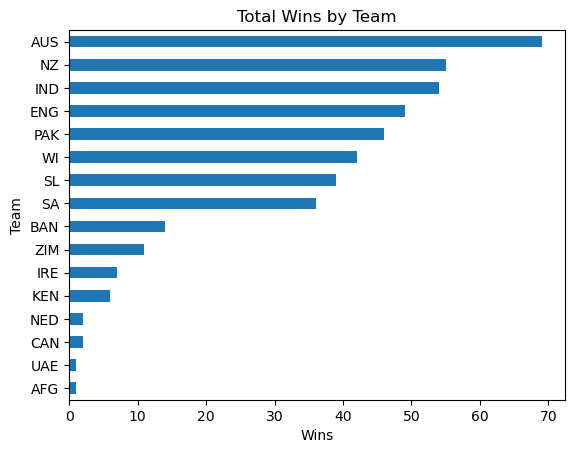

In [60]:
team_wins.sort_values().plot(kind='barh')

plt.xlabel("Wins")
plt.ylabel("Team")
plt.title("Total Wins by Team")
plt.show()

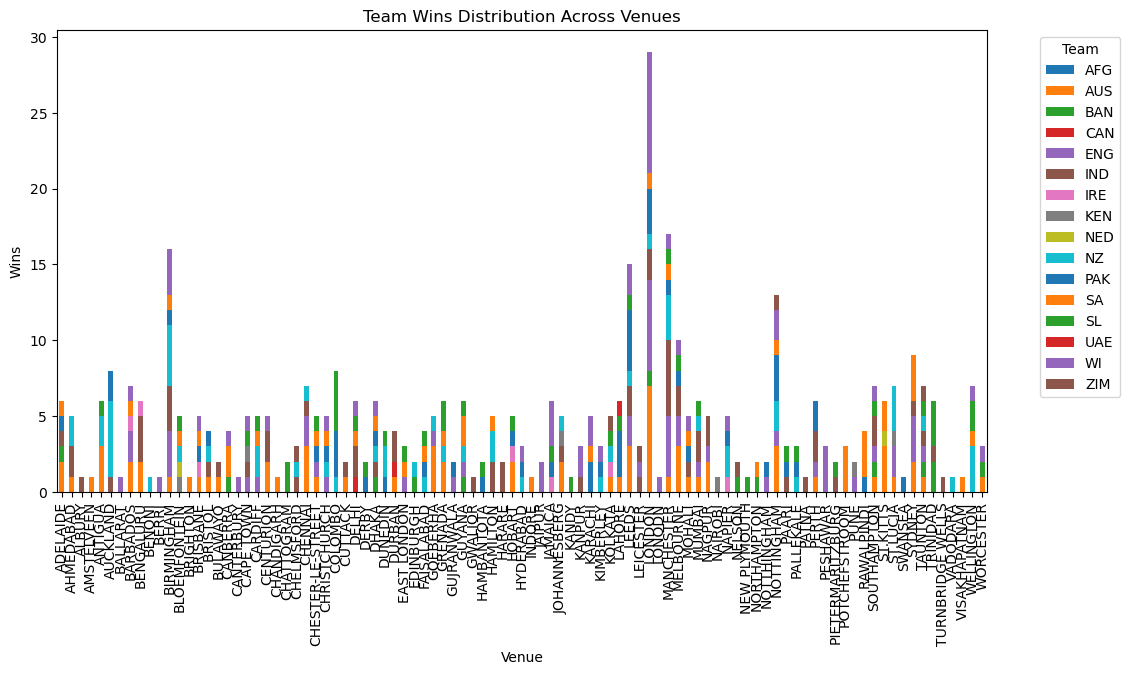

In [61]:
team_venue_wins.T.plot(kind='bar', stacked=True, figsize=(12,6))

plt.xlabel("Venue")
plt.ylabel("Wins")
plt.title("Team Wins Distribution Across Venues")
plt.legend(title="Team", bbox_to_anchor=(1.05, 1))
plt.show()

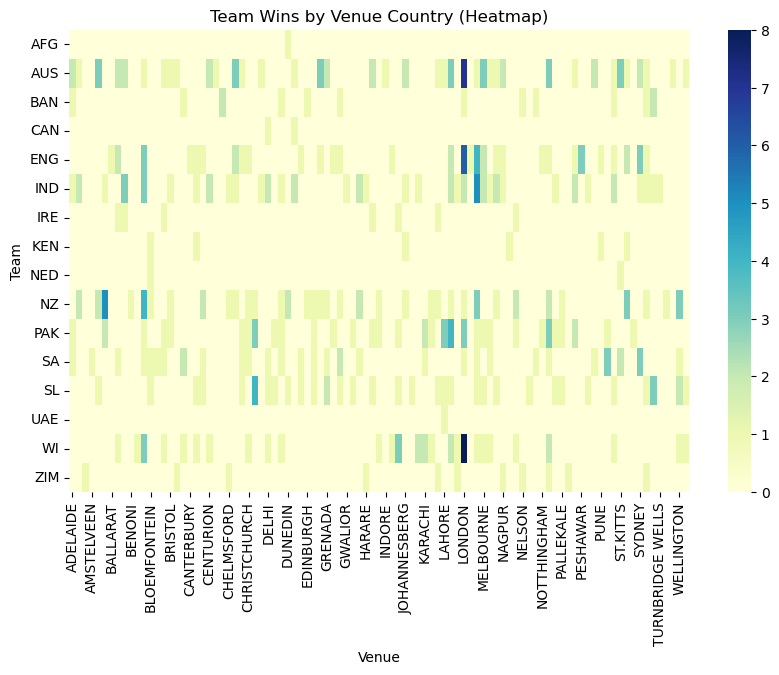

In [75]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(team_venue_wins, cmap="YlGnBu")

plt.title("Team Wins by Venue Country (Heatmap)")
plt.xlabel("Venue")
plt.ylabel("Team")
plt.show()

# **Question 2**

### Who are the teams to beat? Which teams have the lowest amount of losses and does that correlate to more overall world cup wins?

In [19]:
#gathering how many matches each country has played in 
result = pd.read_sql_query("""
    SELECT TEAM, COUNT(TEAM) as matches_played
    FROM cricketold
    GROUP BY TEAM
""", conn)

#gathering how many matches each country has won
result2 = pd.read_sql_query("""
    SELECT TEAM, COUNT(TEAM) as matches_won
    FROM cricketold
    WHERE RESULT = "WON"
    GROUP BY TEAM
""", conn)

#create a dataframe that combines the two tables(matches_ won and matches_played), replace NaN with 0 for any teams that have never won
combo = result.join(result2.set_index("TEAM"), on="TEAM", validate="m:1")
fillcombo = combo.fillna(0)

#creating a new column in the dataframe that calculates the win percentage of each team
fillcombo['win_percentage'] = (fillcombo['matches_won']/fillcombo['matches_played']) *100

#rounding out each column to 1 decimal place or less
roundcombo = fillcombo.round(decimals=1)

#gathering which country has won the cup in each year
cupwins = pd.read_sql_query("""
    SELECT YEAR, TEAM, WINNER
    FROM cricketold
    GROUP BY YEAR
""", conn)

#I manually counted the number of cups each team has won based on the 'cupwins' dataframe and inserted that information as an additional row
roundcombo.insert(4, "cupwins", [0, 5, 0, 0, 0, 0, 1, 2, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 2, 0])

#completed dataframe displaying all the data I need to plot.
print(roundcombo)



   TEAM  matches_played  matches_won  win_percentage  cupwins
0   AFG              15          1.0             6.7        0
1   AUS              96         69.0            71.9        5
2   BAN              42         14.0            33.3        0
3   BER               3          0.0             0.0        0
4   CAN              18          2.0            11.1        0
5    EA               3          0.0             0.0        0
6   ENG              84         49.0            58.3        1
7   IND              85         54.0            63.5        2
8   IRE              21          7.0            33.3        0
9   KEN              29          7.0            24.1        0
10  NAM               6          0.0             0.0        0
11  NED              20          2.0            10.0        0
12   NZ              90         54.0            60.0        0
13  PAK              80         46.0            57.5        1
14   SA              64         36.0            56.2        0
15  SCO 

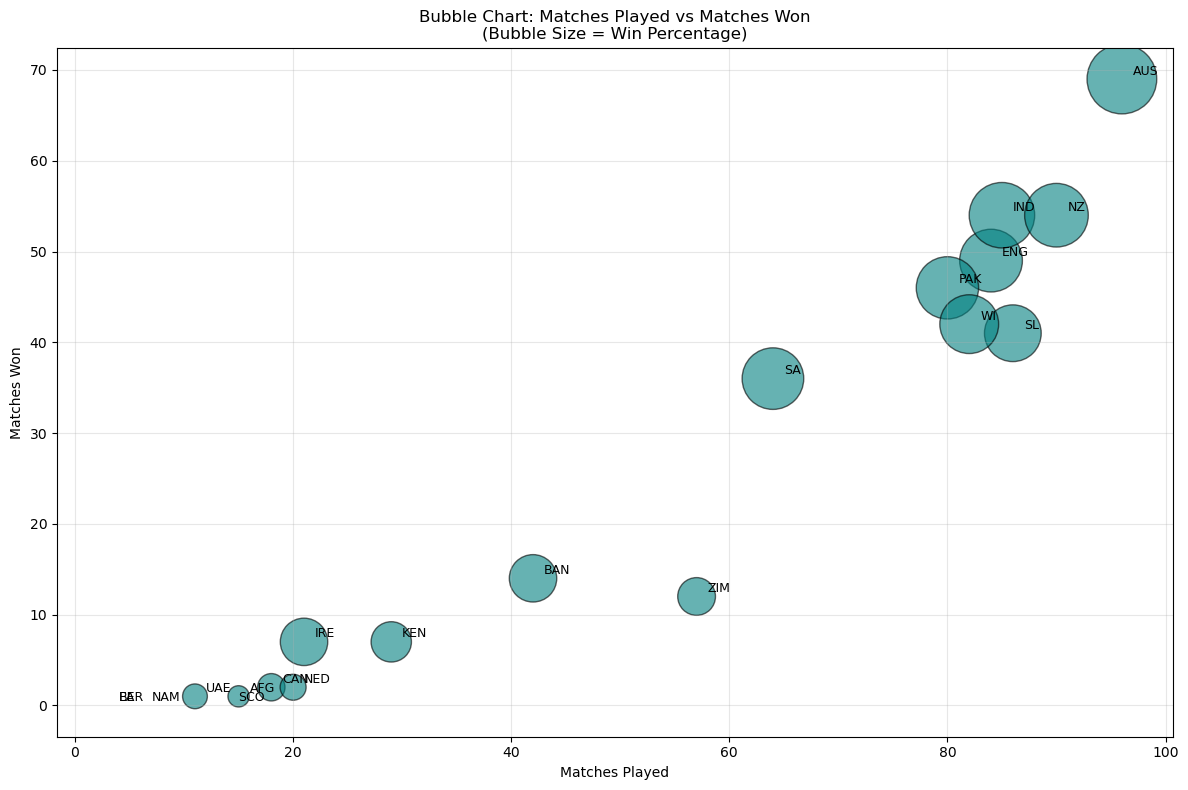

In [76]:
# show matches_played vs. matches_won 


plt.figure(figsize=(12,8))

# Bubble chart
plt.scatter(
    roundcombo['matches_played'],
    roundcombo['matches_won'],
    c='teal',
    s=roundcombo['win_percentage']*35,   
    alpha=0.6,
    edgecolors='black'
)

# Labels
for i, row in roundcombo.iterrows():
    plt.text(
        row['matches_played'] + 1,
        row['matches_won'] + 0.5,
        row['TEAM'],
        fontsize=9
    )

plt.xlabel('Matches Played')
plt.ylabel('Matches Won')
plt.title('Bubble Chart: Matches Played vs Matches Won\n(Bubble Size = Win Percentage)')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



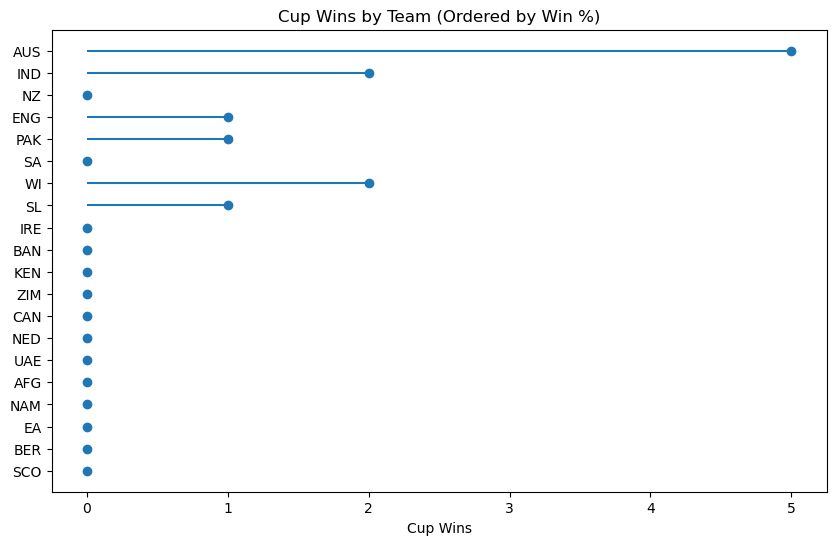

In [23]:
df = roundcombo.sort_values('win_percentage')

plt.figure(figsize=(10,6))

plt.hlines(y=df['TEAM'], xmin=0, xmax=df['cupwins'])
plt.plot(df['cupwins'], df['TEAM'], "o")

plt.xlabel("Cup Wins")
plt.title("Cup Wins by Team (Ordered by Win %)")

plt.show()


# **Question 3**

### Which venues/locations had the best pitch? How do runs made on each location compare to each other and is there a specific location that's most advantageous?

In [13]:
result = pd.read_sql_query("""
    SELECT VENUE, HOST_COUNTRY, AVG(RUNS_SCORED) as avg_runs_scored
    FROM cricket
    GROUP BY VENUE
    ORDER BY avg_runs_scored DESC
    LIMIT 10
""", conn)
print(result)

           VENUE HOST_COUNTRY  avg_runs_scored
0          KANDY         ASIA       326.000000
1        SWANSEA      ENGLAND       313.000000
2   NEW PLYMOUTH       AUS/NZ       312.500000
3         NELSON       AUS/NZ       303.000000
4      BENGALURU    INDIA/PAK       270.214286
5        TAUNTON      ENGLAND       269.583333
6  VISAKHAPATNAM         ASIA       255.500000
7       CANBERRA       AUS/NZ       254.750000
8       BRIGHTON      ENGLAND       253.500000
9         KANPUR    INDIA/PAK       250.833333


In [14]:
host_counts = result['HOST_COUNTRY'].value_counts()
print(host_counts)

HOST_COUNTRY
ENGLAND      3
AUS/NZ       3
ASIA         2
INDIA/PAK    2
Name: count, dtype: int64


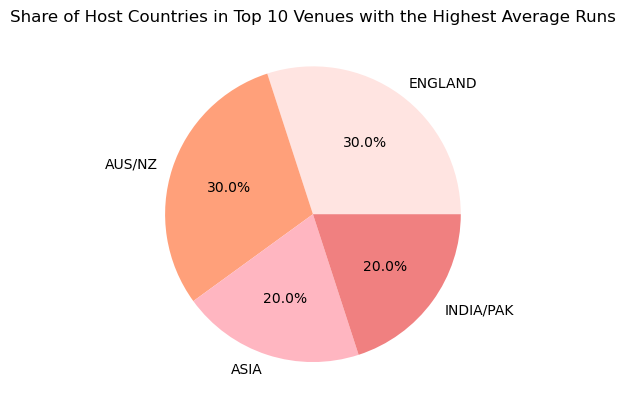

In [81]:


# Define your custom colors
my_colors = ['mistyrose', 'lightsalmon', 'lightpink', 'lightcoral']


host_counts.plot(kind='pie', colors=my_colors, autopct='%1.1f%%')

plt.title('Share of Host Countries in Top 10 Venues with the Highest Average Runs')
plt.ylabel('')
plt.show()

In [41]:
result = pd.read_sql_query("""
    SELECT HOST_COUNTRY, AVG(RUNS_SCORED) as avg_runs_scored
    FROM cricket
    GROUP BY HOST_COUNTRY
    ORDER BY avg_runs_scored DESC
""", conn)
print(result)

   HOST_COUNTRY  avg_runs_scored
0     INDIA/PAK       232.907407
1        AUS/NZ       227.065089
2       ENGLAND       221.783688
3          ASIA       218.849398
4   WEST INDIES       209.147059
5  SOUTH AFRICA       200.950000


<Figure size 1200x600 with 0 Axes>

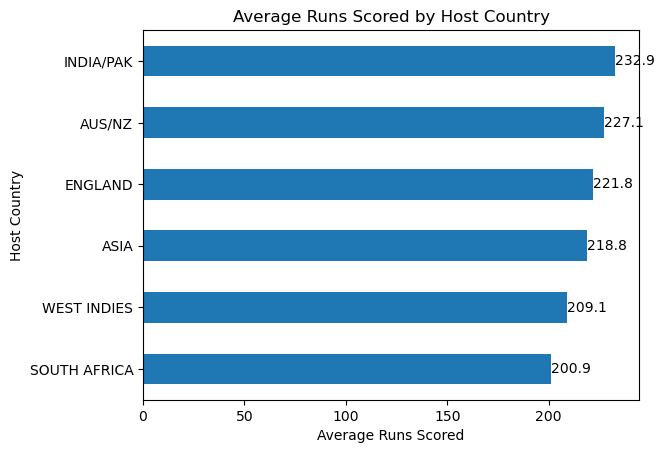

In [47]:
result_sorted = result.sort_values(by='avg_runs_scored', ascending=True)

plt.figure(figsize=(12,6))

ax = result_sorted.plot(
    kind='barh',
    x='HOST_COUNTRY',
    y='avg_runs_scored',
    legend=False
)

# Add labels to each bar
for i, v in enumerate(result_sorted['avg_runs_scored']):
    ax.text(v, i, f"{v:.1f}", va='center', ha='left')

plt.xlabel('Average Runs Scored')
plt.ylabel('Host Country')
plt.title('Average Runs Scored by Host Country')

plt.show()


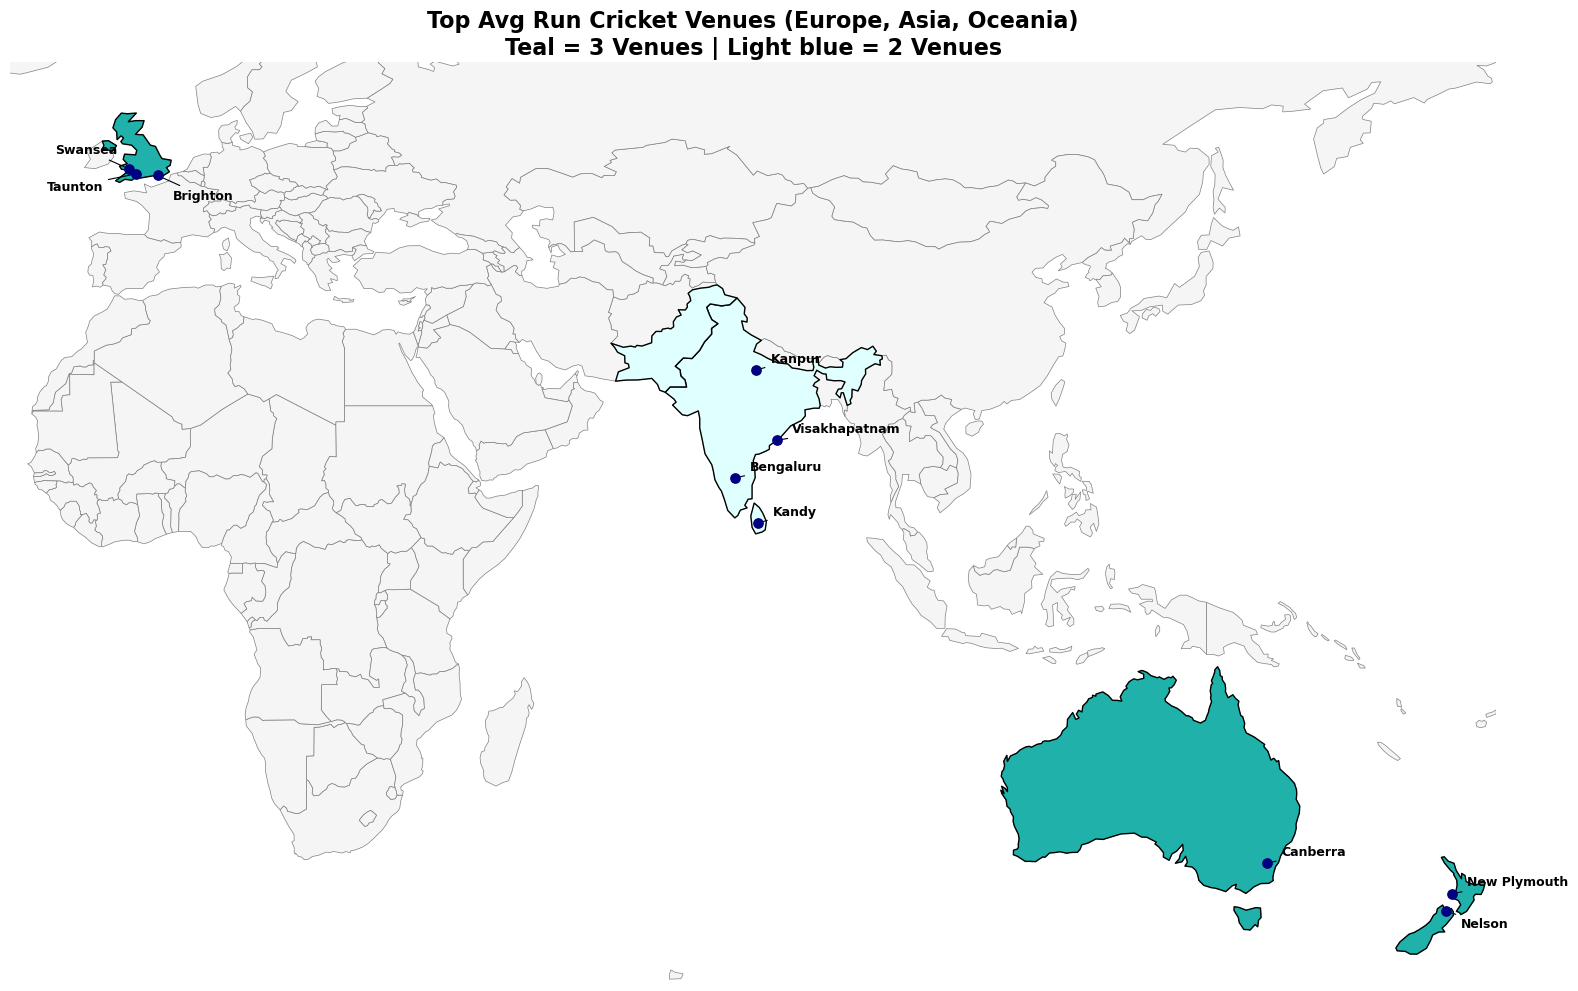

In [37]:
import geopandas as gpd
import matplotlib.pyplot as plt

# ----------------------------
# Load world map
# ----------------------------
url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

# ----------------------------
# Highlight country groups
# ----------------------------
twotimes = ['Sri Lanka', 'India', 'Pakistan']
threetimes = ['United Kingdom', 'New Zealand', 'Australia']

world['high'] = world['NAME'].isin(threetimes)
world['light'] = world['NAME'].isin(twotimes)

# ----------------------------
# Venue coordinates
# ----------------------------
venues = {
    'Kandy': (80.6337, 7.2906),
    'Swansea': (-3.9436, 51.6214),
    'New Plymouth': (174.0752, -39.0556),
    'Nelson': (173.2839, -41.2706),
    'Bengaluru': (77.5946, 12.9716),
    'Taunton': (-3.1047, 51.0153),
    'Visakhapatnam': (83.2185, 17.6868),
    'Canberra': (149.1300, -35.2809),
    'Brighton': (-0.1372, 50.8225),
    'Kanpur': (80.3319, 26.4499)
}

# ----------------------------
# Custom label offsets (fix UK overlap)
# ----------------------------
offsets = {
    'Swansea': (-10, 2),
    'Taunton': (-12, -2),
    'Brighton': (2, -3),
    'Kandy': (2, 1),
    'New Plymouth': (2, 1),
    'Nelson': (2, -2),
    'Bengaluru': (2, 1),
    'Visakhapatnam': (2, 1),
    'Canberra': (2, 1),
    'Kanpur': (2, 1)
}

# ----------------------------
# Plot
# ----------------------------
fig, ax = plt.subplots(figsize=(16,10))

# Base map
world.plot(ax=ax, color='whitesmoke', edgecolor='gray', linewidth=0.5)

# Highlight countries
world[world['high']].plot(ax=ax, color='lightseagreen', edgecolor='black')
world[world['light']].plot(ax=ax, color='lightcyan', edgecolor='black')

# Plot venues + labels
for venue, (lon, lat) in venues.items():
    ax.scatter(lon, lat, color='navy', s=45, zorder=5)

    dx, dy = offsets[venue]

    ax.annotate(
        venue,
        xy=(lon, lat),
        xytext=(lon + dx, lat + dy),
        fontsize=9,
        weight='bold',
        arrowprops=dict(arrowstyle='-', lw=0.8, color='black')
    )

# Zoom to omit Americas
ax.set_xlim(-20, 180)
ax.set_ylim(-50, 65)

# Title
ax.set_title(
    "Top Avg Run Cricket Venues (Europe, Asia, Oceania)\n"
    "Teal = 3 Venues | Light blue = 2 Venues",
    fontsize=16,
    weight='bold'
)

ax.axis('off')

plt.tight_layout()
plt.show()

## **REFLECTION**

In looking at the graph and plot from Question 3, we can see that there isn't just one host country or venue that reigns supreme. Even in counting the number of times the host countries/regions pop up in the top ten, we see that two regions(England and Aus/NZ) appreared 3 times and two regions(India/Pak, Asia) appeared 2 times. No country appears more than the other. This indicated that the venues and pitch are most likely well balanced.